Just some test

In [99]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

# import matplotlib
import matplotlib.pyplot as plt

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.encoders import Encoder
from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects


## 1. Encoder test

In [100]:
model_encoder = Encoder(in_ch = 1, out_ch = 128, dim = 32, dropout=0.5)

# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(f"Warstwa: {name} | Rozmiar: {param.size()} | Liczba elementów: {param.numel()}")


# print(model)

In [101]:
# example of data
data_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'
new_frame = cv2.imread(data_pth, 0)
# print(f'sample size: sample.shape')

sample = torch.from_numpy(new_frame.copy()) # convert to torch tensor
sample = sample.float()
sample = sample.unsqueeze(0) # add channels num dimension
sample = sample.unsqueeze(0) # add batch size dimension

print(f'tensor shape: {sample.shape}, data type: {sample.dtype}')


tensor shape: torch.Size([1, 1, 800, 768]), data type: torch.float32


In [102]:
# pass through encoder -> downsized 4 times
output = model_encoder(sample)
print(f'output shape: {output.shape}')



output shape: torch.Size([1, 128, 200, 192])


## 2. Patch extraction test

### 2.1 Gradient base method

- use Gaussian filter to reduce noise on img 
- calc gradient
- extract areas with stronger gradient

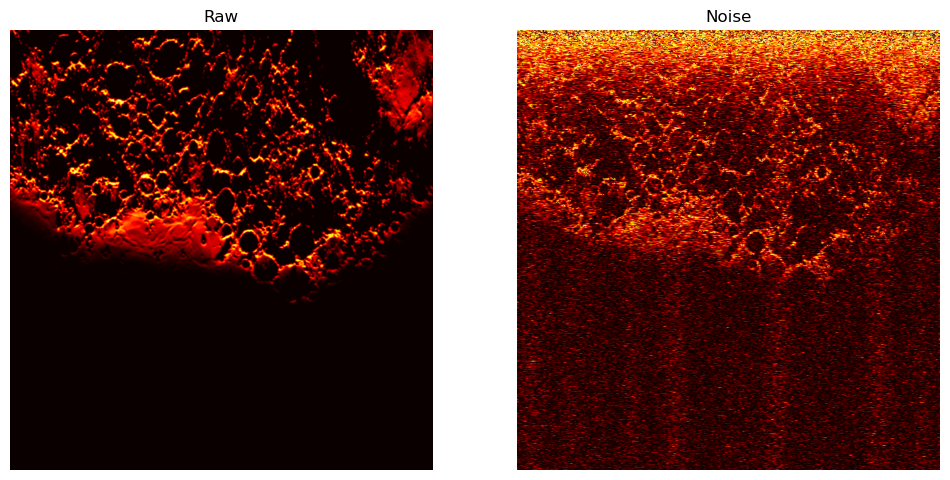

In [103]:
noise_frame = new_frame.copy()
noise_frame = addBandReflects(noise_frame, omega1 = 0.03, omega2 = 0.07, gain = 0.02)
noise_frame = energyLoss(noise_frame, alpha = 0.02)
noise_frame = addSpeckleNoise(noise_frame, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)
noise_frame = noise_frame.astype(np.uint8)

plt.figure(figsize=(12, 10))
# plt.imshow(noise_frame, cmap = 'hot')
# plt.axis('off')

plt.subplot(1, 2, 1)
plt.title("Raw")
plt.imshow(new_frame, cmap='hot')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Noise")
plt.imshow(noise_frame, cmap='hot')
plt.axis('off')

plt.show()


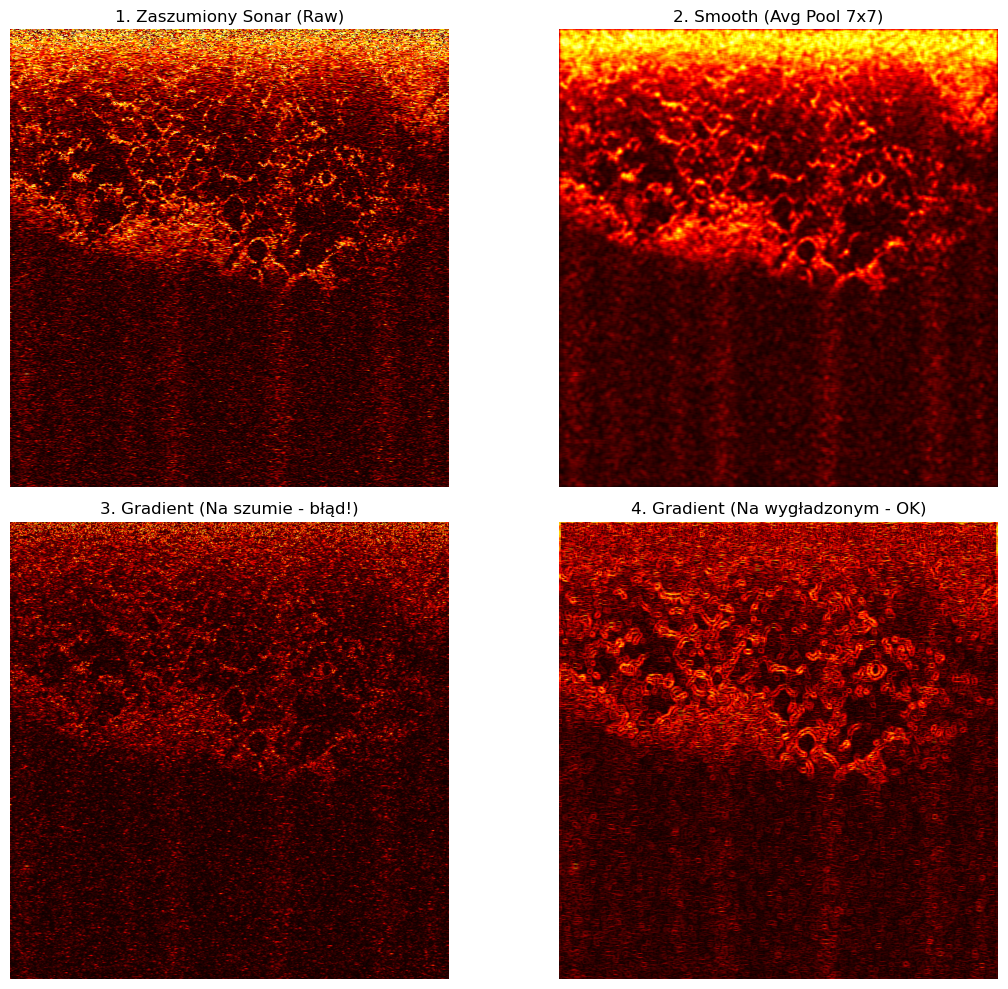

In [104]:
noise_tensor = torch.from_numpy(noise_frame).float().unsqueeze(0).unsqueeze(0)

# raw gradient
dx_raw = noise_tensor[...,:-1,1:] - noise_tensor[...,:-1,:-1]
dy_raw = noise_tensor[...,1:,:-1] - noise_tensor[...,:-1,:-1]
g_raw = torch.sqrt(dx_raw**2 + dy_raw**2)

# g_raw_final = F.avg_pool2d(g_raw, 4, 4) pooling for dimension correction

# smooth gradient
smooth_tensor = F.avg_pool2d(noise_tensor, kernel_size=7, stride=1, padding=3)
dx_smooth = smooth_tensor[...,:-1,1:] - smooth_tensor[...,:-1,:-1]
dy_smooth = smooth_tensor[...,1:,:-1] - smooth_tensor[...,:-1,:-1]
g_smooth = torch.sqrt(dx_smooth**2 + dy_smooth**2)

# g_smooth_final = F.avg_pool2d(g_smooth, 4, 4) # pooling for dimension correction

def normalize_for_plot(tensor):
    t = tensor.squeeze().cpu().numpy()
    t_min = t.min()
    t_max = t.max()
    if t_max - t_min > 1e-5:
        t = (t - t_min) / (t_max - t_min)
    return t


plt.figure(figsize=(12, 10))

# Orginal
plt.subplot(2, 2, 1)
plt.title("1. Zaszumiony Sonar (Raw)")
plt.imshow(noise_frame, cmap='hot')
plt.axis('off')

# Smooth
plt.subplot(2, 2, 2)
plt.title("2. Smooth (Avg Pool 7x7)")
plt.imshow(normalize_for_plot(smooth_tensor), cmap='hot')
plt.axis('off')

# Raw grad
plt.subplot(2, 2, 3)
plt.title("3. Gradient (Na szumie - błąd!)")
plt.imshow(normalize_for_plot(g_raw), cmap='hot')
plt.axis('off')

# Smooth grad
plt.subplot(2, 2, 4)
plt.title("4. Gradient (Na wygładzonym - OK)")
plt.imshow(normalize_for_plot(g_smooth), cmap='hot')
plt.axis('off')

plt.tight_layout()
plt.show()

**Lee filter/ Frost filter**
- calculate local variance (eg. in window 7x7)
- when there is no texture, variance comes only from noise - const value
- whene there are textures, variance grows immidietly 


In [105]:
def lee_filter(frame, ksize=7, pad=3, noise_mul=5.0):
    # 1. E(x) - local mean
    mean = F.avg_pool2d(frame, ksize, stride=1, padding=pad)
    
    # 2. E(x^2) - local square mean
    mean_sq = F.avg_pool2d(frame**2, ksize, stride=1, padding=pad)
    
    # 3. Var(x) = E(x^2) - [E(x)]^2 
    var = mean_sq - mean**2
    var = torch.clamp(var, min=0) # Numerical error protection
    
    # 4. Apriximate noise var
    noise_var = torch.mean(var) * noise_mul
    
    # 5. gain k = Var(x) / (Var(x) + noise_var)
    k = var / (var + noise_var + 1e-8)
    
    # 6. Output filtered image: mean + k * (frame - mean)
    return mean + k * (frame - mean)

In [ ]:
def harris_response(frame, ksize=7, padding = 3):
    
    # Gradients x and y
    dx = F.pad(frame[...,:,1:] - frame[...,:,:-1], (0,1,0,0))
    dy = F.pad(frame[...,1:,:] - frame[...,:-1,:], (0,0,0,1))
    
    # Structural matrix components
    Ixx = F.avg_pool2d(dx**2, ksize, stride=1, padding=padding)
    Iyy = F.avg_pool2d(dy**2, ksize, stride=1, padding=padding)
    Ixy = F.avg_pool2d(dx*dy, ksize, stride=1, padding=padding)
    
    # Shi-Tomasi response (min eigenvalue form)
    # determinant = Ixx*Iyy - Ixy**2, trace = Ixx + Iyy
    trace = Ixx + Iyy
    determinant = Ixx * Iyy - Ixy**2
    
    response = determinant / (trace + 1e-8)
    return response

noise tensor shape: torch.Size([1, 1, 800, 768])


(-0.5, 767.5, 799.5, -0.5)

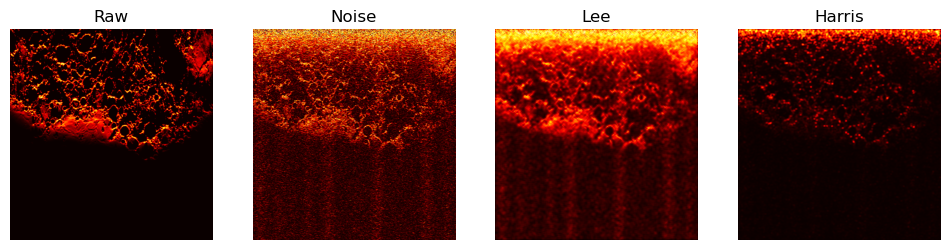

In [107]:
noise_tensor = torch.from_numpy(noise_frame).float().unsqueeze(0).unsqueeze(0)
print(f'noise tensor shape: {noise_tensor.shape}')
lee_tensor = lee_filter(noise_tensor , ksize=11, pad=5, noise_mul = 10.0)
harris_tensor = harris_response(noise_tensor)
plt.figure(figsize=(12, 10))

# Orginal
plt.subplot(1, 4, 1)
plt.title("Raw")
plt.imshow(new_frame, cmap='hot')
plt.axis('off')

# Noise
plt.subplot(1, 4, 2)
plt.title("Noise")
plt.imshow(normalize_for_plot(noise_tensor), cmap='hot')
plt.axis('off')

# Lee filter 
plt.subplot(1, 4, 3)
plt.title("Lee")
plt.imshow(normalize_for_plot(lee_tensor), cmap='hot')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Harris")
plt.imshow(normalize_for_plot(harris_tensor), cmap='hot')
plt.axis('off')